<a href="https://colab.research.google.com/github/singhaastha88385/projects/blob/main/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
====================================================
  TITANIC SURVIVAL PREDICTION - Full ML Project
====================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────
# STEP 1: CREATE DATASET (Titanic-style synthetic data)
# ─────────────────────────────────────────────────────────
np.random.seed(42)
n = 891

pclass = np.random.choice([1, 2, 3], size=n, p=[0.24, 0.21, 0.55])
sex    = np.random.choice(['male', 'female'], size=n, p=[0.65, 0.35])
age    = np.random.normal(29.7, 14.5, n).clip(1, 80)
sibsp  = np.random.choice([0,1,2,3,4,5], size=n, p=[0.68,0.23,0.05,0.02,0.01,0.01])
parch  = np.random.choice([0,1,2,3,4],   size=n, p=[0.76,0.13,0.08,0.02,0.01])
fare   = np.where(pclass==1, np.random.exponential(80,n),
         np.where(pclass==2, np.random.exponential(20,n),
                             np.random.exponential(13,n))).clip(0, 512)
embarked = np.random.choice(['S','C','Q'], size=n, p=[0.72,0.19,0.09])

# Survival probability based on real Titanic patterns
surv_prob = (
    0.15
    + 0.40 * (sex == 'female')
    - 0.10 * (pclass == 3)
    + 0.10 * (pclass == 1)
    + 0.05 * (age < 15)
    - 0.05 * (age > 60)
    + 0.03 * (embarked == 'C')
).clip(0.05, 0.95)
survived = (np.random.rand(n) < surv_prob).astype(int)

# Introduce some missing values
age_missing = age.copy().astype(float)
age_missing[np.random.choice(n, 177, replace=False)] = np.nan
embarked_missing = embarked.copy().astype(object)
embarked_missing[np.random.choice(n, 2, replace=False)] = np.nan

df = pd.DataFrame({
    'PassengerId': range(1, n+1),
    'Survived':   survived,
    'Pclass':     pclass,
    'Sex':        sex,
    'Age':        age_missing,
    'SibSp':      sibsp,
    'Parch':      parch,
    'Fare':       np.round(fare, 2),
    'Embarked':   embarked_missing
})

print("=" * 55)
print("  TITANIC SURVIVAL PREDICTION — Full ML Project")
print("=" * 55)
print(f"\n📦 Dataset shape: {df.shape}")
print(f"   Survived: {survived.sum()} ({survived.mean()*100:.1f}%)")
print(f"   Did not survive: {(1-survived).sum()} ({(1-survived.mean())*100:.1f}%)")

# ─────────────────────────────────────────────────────────
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────────────────
print("\n── Missing Values ──────────────────────────────────")
print(df.isnull().sum()[df.isnull().sum() > 0])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic EDA — Survival Patterns", fontsize=16, fontweight='bold', y=1.01)

# 1. Survival count
ax = axes[0, 0]
counts = df['Survived'].value_counts()
bars = ax.bar(['Did Not Survive', 'Survived'], counts.values, color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontweight='bold')
ax.set_title('Overall Survival Count', fontweight='bold')
ax.set_ylabel('Count')

# 2. Survival by Sex
ax = axes[0, 1]
surv_sex = df.groupby('Sex')['Survived'].mean() * 100
ax.bar(surv_sex.index, surv_sex.values, color=['#3498db','#e91e63'], edgecolor='white')
for i, v in enumerate(surv_sex.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Survival Rate by Sex', fontweight='bold')
ax.set_ylabel('Survival Rate (%)')

# 3. Survival by Pclass
ax = axes[0, 2]
surv_class = df.groupby('Pclass')['Survived'].mean() * 100
ax.bar(['1st Class','2nd Class','3rd Class'], surv_class.values, color=['#f1c40f','#95a5a6','#cd6133'], edgecolor='white')
for i, v in enumerate(surv_class.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Survival Rate by Class', fontweight='bold')
ax.set_ylabel('Survival Rate (%)')

# 4. Age distribution
ax = axes[1, 0]
df[df['Survived']==0]['Age'].dropna().hist(ax=ax, bins=25, alpha=0.6, color='#e74c3c', label='Did Not Survive')
df[df['Survived']==1]['Age'].dropna().hist(ax=ax, bins=25, alpha=0.6, color='#2ecc71', label='Survived')
ax.legend()
ax.set_title('Age Distribution by Survival', fontweight='bold')
ax.set_xlabel('Age')

# 5. Fare distribution
ax = axes[1, 1]
df[df['Survived']==0]['Fare'].hist(ax=ax, bins=30, alpha=0.6, color='#e74c3c', label='Did Not Survive')
df[df['Survived']==1]['Fare'].hist(ax=ax, bins=30, alpha=0.6, color='#2ecc71', label='Survived')
ax.legend()
ax.set_title('Fare Distribution by Survival', fontweight='bold')
ax.set_xlabel('Fare')

# 6. Embarked survival rate
ax = axes[1, 2]
surv_emb = df.groupby('Embarked')['Survived'].mean() * 100
ax.bar(surv_emb.index, surv_emb.values, color=['#9b59b6','#1abc9c','#e67e22'], edgecolor='white')
for i, v in enumerate(surv_emb.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Survival Rate by Embarked Port', fontweight='bold')
ax.set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n✅ EDA chart saved.")

# ─────────────────────────────────────────────────────────
# STEP 3: DATA CLEANING & FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────
print("\n── Data Cleaning & Feature Engineering ─────────────")

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels=[0,1,2,3,4]).cat.add_categories([-1]).fillna(-1).astype(int).replace(-1, 2)

le = LabelEncoder()
df['Sex_enc']      = le.fit_transform(df['Sex'])
df['Embarked_enc'] = le.fit_transform(df['Embarked'])

features = ['Pclass','Sex_enc','AgeBand','SibSp','Parch','Fare',
            'Embarked_enc','FamilySize','IsAlone','FarePerPerson']
X = df[features]
y = df['Survived']

print(f"   Features used: {features}")
print(f"   Missing values after cleaning: {X.isnull().sum().sum()}")

# ─────────────────────────────────────────────────────────
# STEP 4: TRAIN/TEST SPLIT
# ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n── Train/Test Split ─────────────────────────────────")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing  samples : {len(X_test)}")

# ─────────────────────────────────────────────────────────
# STEP 5: TRAIN MULTIPLE MODELS
# ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression':    LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                    SVC(probability=True, random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=5),
}

results = {}
print("\n── Model Training & Evaluation ──────────────────────")
print(f"{'Model':<25} {'Accuracy':>10} {'CV Score':>10} {'ROC-AUC':>10}")
print("-" * 58)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    cv      = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    auc     = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'acc': acc, 'cv': cv, 'auc': auc,
                     'y_pred': y_pred, 'y_proba': y_proba}
    print(f"{name:<25} {acc*100:>9.2f}% {cv*100:>9.2f}% {auc:>10.4f}")

# ─────────────────────────────────────────────────────────
# STEP 6: BEST MODEL DEEP DIVE
# ─────────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['cv'])
best      = results[best_name]
print(f"\n🏆 Best Model: {best_name} (CV Accuracy: {best['cv']*100:.2f}%)")
print("\n── Classification Report ────────────────────────────")
print(classification_report(y_test, best['y_pred'], target_names=['Did Not Survive','Survived']))

# ─────────────────────────────────────────────────────────
# STEP 7: VISUALIZATIONS — Model Comparison + Feature Importance + ROC
# ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Titanic ML — Model Results & Analysis", fontsize=16, fontweight='bold')

# 1. Model comparison (accuracy)
ax1 = fig.add_subplot(gs[0, 0])
names = list(results.keys())
accs  = [results[n]['acc']*100 for n in names]
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars  = ax1.barh(names, accs, color=colors, edgecolor='white')
ax1.set_xlabel('Accuracy (%)')
ax1.set_title('Model Accuracy Comparison', fontweight='bold')
ax1.set_xlim(50, 100)
for bar, v in zip(bars, accs):
    ax1.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)

# 2. CV Score comparison
ax2 = fig.add_subplot(gs[0, 1])
cvs  = [results[n]['cv']*100 for n in names]
colors2 = ['#2ecc71' if n == best_name else '#e67e22' for n in names]
bars2 = ax2.barh(names, cvs, color=colors2, edgecolor='white')
ax2.set_xlabel('CV Accuracy (%)')
ax2.set_title('Cross-Validation Score', fontweight='bold')
ax2.set_xlim(50, 100)
for bar, v in zip(bars2, cvs):
    ax2.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)

# 3. ROC Curves
ax3 = fig.add_subplot(gs[0, 2])
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
for (name, res), col in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax3.plot(fpr, tpr, label=f"{name} ({res['auc']:.2f})", color=col, linewidth=1.5)
ax3.plot([0,1],[0,1],'k--', alpha=0.4)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves (All Models)', fontweight='bold')
ax3.legend(fontsize=6.5, loc='lower right')

# 4. Confusion Matrix (best model)
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
ax4.set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')

# 5. Feature Importance (Random Forest)
ax5 = fig.add_subplot(gs[1, 1])
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=ax5, color='#3498db', edgecolor='white')
ax5.set_title('Feature Importance\n(Random Forest)', fontweight='bold')
ax5.set_xlabel('Importance Score')

# 6. Survival heatmap by Sex & Pclass
ax6 = fig.add_subplot(gs[1, 2])
pivot = df.pivot_table('Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax6, vmin=0, vmax=100,
            cbar_kws={'label': 'Survival Rate (%)'})
ax6.set_title('Survival Rate (%)\nby Sex & Class', fontweight='bold')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n✅ Model results chart saved.")

# ─────────────────────────────────────────────────────────
# STEP 8: PREDICTION EXAMPLES
# ─────────────────────────────────────────────────────────
print("\n── Sample Predictions (Random Forest) ──────────────")
sample = pd.DataFrame({
    'Pclass':        [1,    3,    2,    3],
    'Sex_enc':       [1,    0,    1,    0],   # 1=male, 0=female
    'AgeBand':       [2,    2,    0,    3],   # 0=child, 2=adult, 3=older
    'SibSp':         [0,    1,    1,    0],
    'Parch':         [0,    0,    1,    0],
    'Fare':          [100,  8,   30,   12],
    'Embarked_enc':  [0,    2,    0,    2],
    'FamilySize':    [1,    2,    3,    1],
    'IsAlone':       [1,    0,    0,    1],
    'FarePerPerson': [100,  4,   10,   12],
})
rf = results['Random Forest']['model']
preds  = rf.predict(sample)
probas = rf.predict_proba(sample)[:, 1]
descs  = ['1st class adult male','3rd class adult female','2nd class child male','3rd class older male']
print(f"{'Passenger':<30} {'Prediction':>12} {'Survival Prob':>15}")
print("-" * 58)
for desc, pred, prob in zip(descs, preds, probas):
    outcome = "✅ SURVIVED" if pred == 1 else "❌ NOT SURVIVED"
    print(f"{desc:<30} {outcome:>12}   {prob*100:>8.1f}%")

print("\n" + "=" * 55)
print("  ✅ Project Complete!")
print("  📊 Charts saved to outputs/")
print("=" * 55)


  TITANIC SURVIVAL PREDICTION — Full ML Project

📦 Dataset shape: (891, 9)
   Survived: 253 (28.4%)
   Did not survive: 638 (71.6%)

── Missing Values ──────────────────────────────────
Age         177
Embarked      2
dtype: int64

✅ EDA chart saved.

── Data Cleaning & Feature Engineering ─────────────
   Features used: ['Pclass', 'Sex_enc', 'AgeBand', 'SibSp', 'Parch', 'Fare', 'Embarked_enc', 'FamilySize', 'IsAlone', 'FarePerPerson']
   Missing values after cleaning: 0

── Train/Test Split ─────────────────────────────────
   Training samples : 712
   Testing  samples : 179

── Model Training & Evaluation ──────────────────────
Model                       Accuracy   CV Score    ROC-AUC
----------------------------------------------------------
Logistic Regression           79.89%     79.23%     0.8534
Decision Tree                 77.09%     74.74%     0.8074
Random Forest                 77.65%     72.84%     0.7931
Gradient Boosting             77.65%     75.42%     0.8244
SVM     

In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

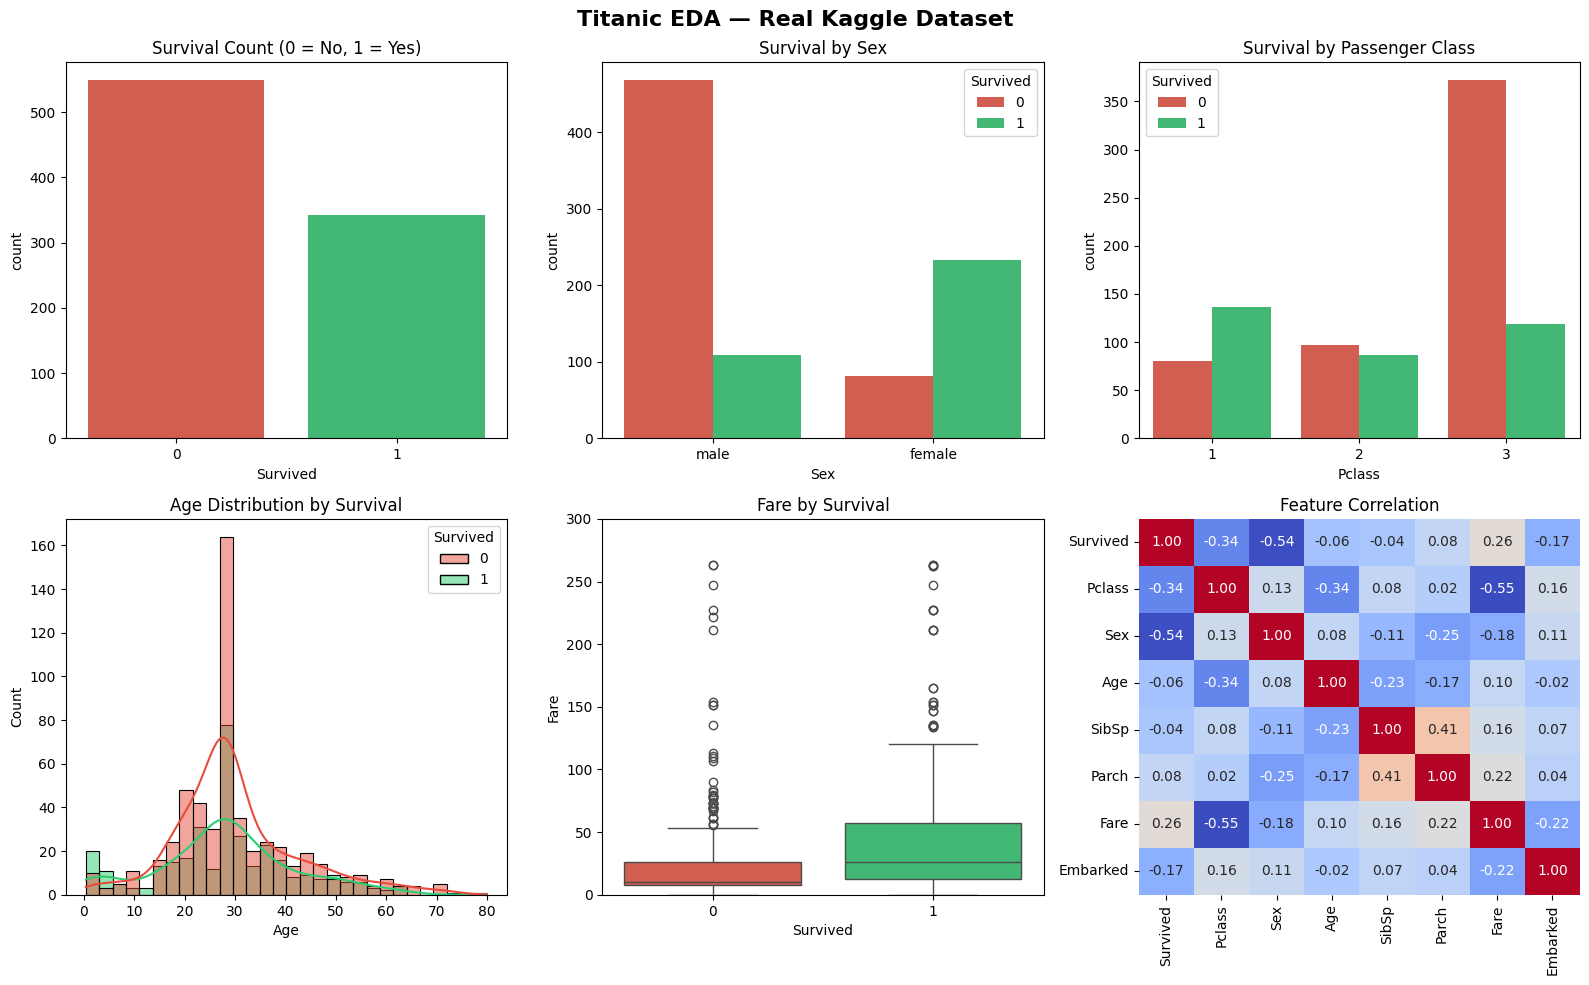


✅ EDA chart saved as eda_analysis.png

Training set: 712 samples
Test set: 179 samples

Logistic Regression
  Test Accuracy: 0.804
  CV Accuracy:   0.798 (+/- 0.019)

Decision Tree
  Test Accuracy: 0.832
  CV Accuracy:   0.785 (+/- 0.032)

Random Forest
  Test Accuracy: 0.832
  CV Accuracy:   0.799 (+/- 0.047)

Gradient Boosting
  Test Accuracy: 0.799
  CV Accuracy:   0.809 (+/- 0.032)

SVM
  Test Accuracy: 0.620
  CV Accuracy:   0.691 (+/- 0.022)

KNN
  Test Accuracy: 0.648
  CV Accuracy:   0.737 (+/- 0.043)

🏆 Best Model: Gradient Boosting

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



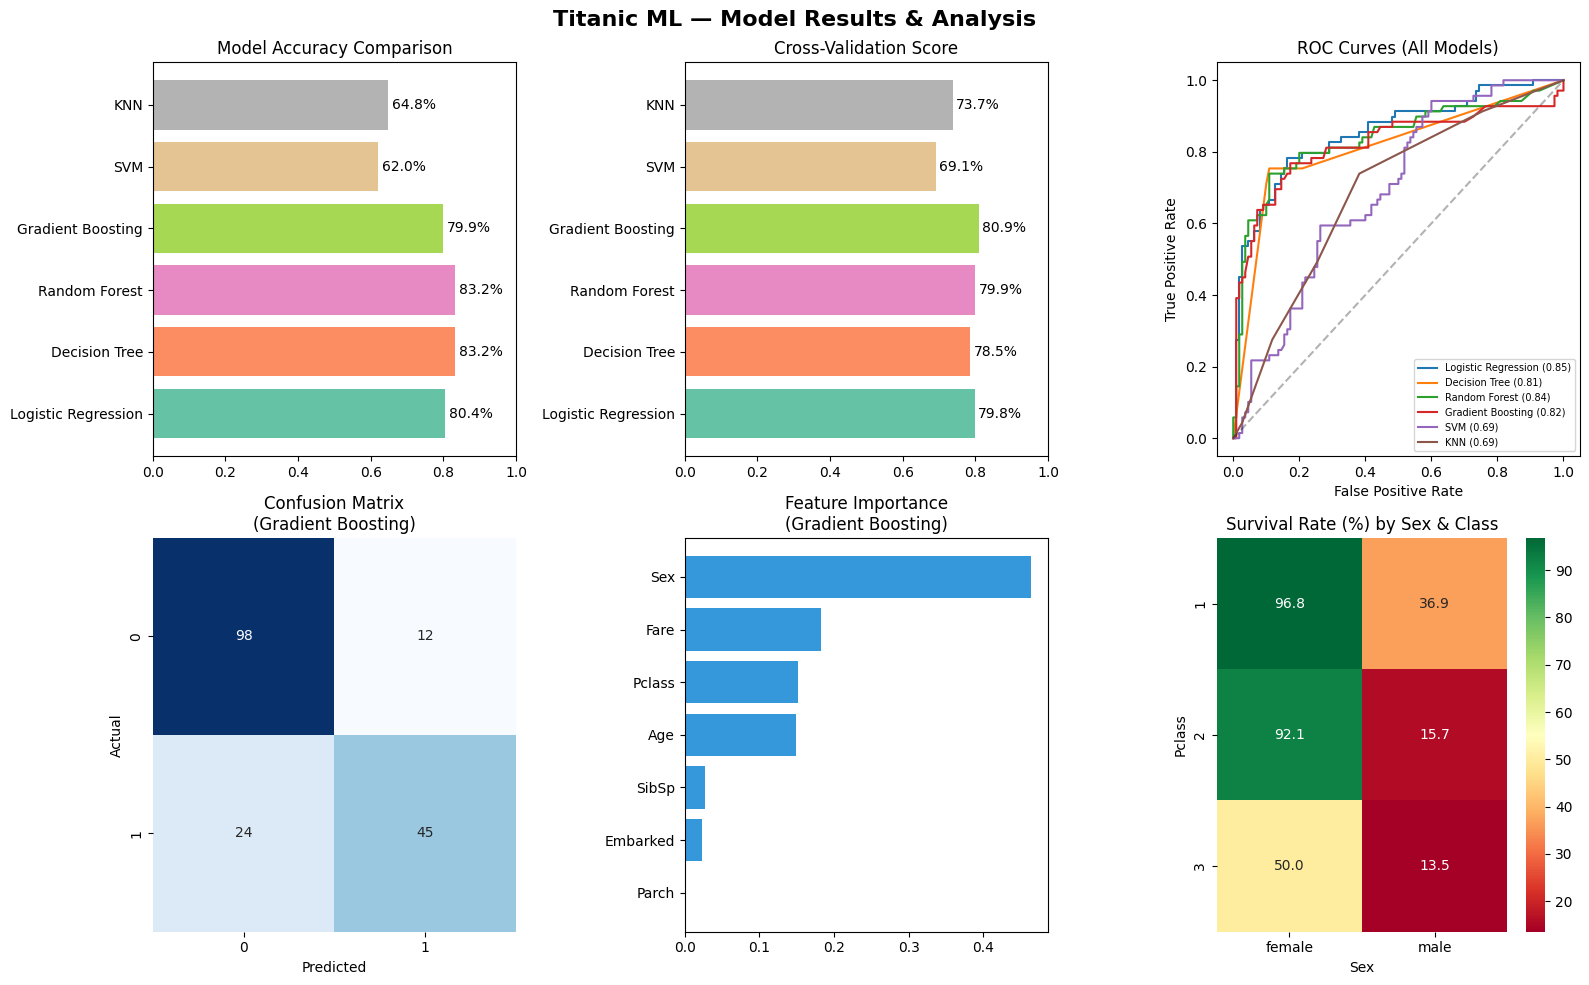


✅ Model results chart saved as model_results.png

Sample Predictions (Gradient Boosting)
3rd class male, age 24 -> Predicted: NOT SURVIVE, Actual: NOT SURVIVE  [✅ CORRECT]
3rd class male, age 44 -> Predicted: NOT SURVIVE, Actual: NOT SURVIVE  [✅ CORRECT]
3rd class male, age 22 -> Predicted: NOT SURVIVE, Actual: SURVIVED  [❌ WRONG]
3rd class male, age 41 -> Predicted: NOT SURVIVE, Actual: NOT SURVIVE  [✅ CORRECT]
3rd class female, age 28 -> Predicted: SURVIVED, Actual: SURVIVED  [✅ CORRECT]

PROJECT COMPLETE


In [ ]:
"""
==========================================================
  TITANIC SURVIVAL PREDICTION - Full ML Project
==========================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings("ignore")

# ----------------------------------------------------------
# STEP 1: LOAD REAL DATASET (Kaggle Titanic - train.csv)
# ----------------------------------------------------------
# Make sure train.csv has been uploaded to Colab's session storage
# (Files panel -> upload arrow -> select train.csv)

df = pd.read_csv('train.csv')
print("Dataset shape:", df.shape)
print(df.head())

# ----------------------------------------------------------
# STEP 2: BASIC CLEANING
# ----------------------------------------------------------
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode (most common port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing Fare with median (mainly relevant for test.csv, but safe here too)
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop columns that aren't useful for modeling in this simple pipeline
# (Cabin has too many missing values; Name/Ticket/PassengerId aren't predictive as-is)
df_model = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

print("\nMissing values after cleaning:")
print(df_model.isnull().sum())

# ----------------------------------------------------------
# STEP 3: ENCODE CATEGORICAL FEATURES
# ----------------------------------------------------------
le_sex = LabelEncoder()
df_model['Sex'] = le_sex.fit_transform(df_model['Sex'])  # male=1, female=0 (alphabetical)

le_embarked = LabelEncoder()
df_model['Embarked'] = le_embarked.fit_transform(df_model['Embarked'])

# ----------------------------------------------------------
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Titanic EDA — Real Kaggle Dataset", fontsize=16, fontweight='bold')

# Survival count
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df, x='Survived', ax=ax1, palette=['#e74c3c', '#2ecc71'])
ax1.set_title('Survival Count (0 = No, 1 = Yes)')

# Survival by sex
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df, x='Sex', hue='Survived', ax=ax2, palette=['#e74c3c', '#2ecc71'])
ax2.set_title('Survival by Sex')

# Survival by class
ax3 = fig.add_subplot(gs[0, 2])
sns.countplot(data=df, x='Pclass', hue='Survived', ax=ax3, palette=['#e74c3c', '#2ecc71'])
ax3.set_title('Survival by Passenger Class')

# Age distribution
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=ax4, palette=['#e74c3c', '#2ecc71'])
ax4.set_title('Age Distribution by Survival')

# Fare distribution
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x='Survived', y='Fare', ax=ax5, palette=['#e74c3c', '#2ecc71'])
ax5.set_title('Fare by Survival')
ax5.set_ylim(0, 300)

# Correlation heatmap
ax6 = fig.add_subplot(gs[1, 2])
corr = df_model.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax6, cbar=False)
ax6.set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA chart saved as eda_analysis.png")

# ----------------------------------------------------------
# STEP 5: TRAIN/TEST SPLIT
# ----------------------------------------------------------
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ----------------------------------------------------------
# STEP 6: TRAIN MULTIPLE MODELS
# ----------------------------------------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    results[name] = {
        'accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': preds,
    }
    trained_models[name] = model

    print(f"\n{name}")
    print(f"  Test Accuracy: {acc:.3f}")
    print(f"  CV Accuracy:   {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# ----------------------------------------------------------
# STEP 7: PICK BEST MODEL
# ----------------------------------------------------------
best_model_name = max(results, key=lambda k: results[k]['cv_mean'])
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")

best_preds = best_model.predict(X_test)
print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_preds))

# ----------------------------------------------------------
# STEP 8: VISUALIZE RESULTS
# ----------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Titanic ML — Model Results & Analysis", fontsize=16, fontweight='bold')

# Accuracy comparison
ax1 = fig.add_subplot(gs[0, 0])
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
ax1.barh(names, accs, color=colors)
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlim(0, 1)
for i, v in enumerate(accs):
    ax1.text(v + 0.01, i, f'{v:.1%}', va='center')

# CV score comparison
ax2 = fig.add_subplot(gs[0, 1])
cv_means = [results[n]['cv_mean'] for n in names]
ax2.barh(names, cv_means, color=colors)
ax2.set_title('Cross-Validation Score')
ax2.set_xlim(0, 1)
for i, v in enumerate(cv_means):
    ax2.text(v + 0.01, i, f'{v:.1%}', va='center')

# ROC curves
ax3 = fig.add_subplot(gs[0, 2])
for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax3.plot(fpr, tpr, label=f'{name} ({auc:.2f})')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax3.set_title('ROC Curves (All Models)')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)

# Confusion matrix (best model)
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False)
ax4.set_title(f'Confusion Matrix\n({best_model_name})')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# Feature importance (if available)
ax5 = fig.add_subplot(gs[1, 1])
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
    ax5.barh(importances.index, importances.values, color='#3498db')
    ax5.set_title(f'Feature Importance\n({best_model_name})')
else:
    ax5.text(0.5, 0.5, f'{best_model_name} has\nno feature_importances_',
              ha='center', va='center')
    ax5.set_title('Feature Importance')

# Survival rate heatmap by Sex & Class
ax6 = fig.add_subplot(gs[1, 2])
pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax6, cbar=True)
ax6.set_title('Survival Rate (%) by Sex & Class')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model results chart saved as model_results.png")

# ----------------------------------------------------------
# STEP 9: SAMPLE PREDICTIONS
# ----------------------------------------------------------
print("\n" + "=" * 60)
print(f"Sample Predictions ({best_model_name})")
print("=" * 60)

sample_idx = X_test.index[:5]
for idx in sample_idx:
    row = df.loc[idx]
    pred = best_model.predict(X_test.loc[[idx]])[0]
    actual = y_test.loc[idx]
    status = "✅ CORRECT" if pred == actual else "❌ WRONG"
    pclass_label = {1: '1st', 2: '2nd', 3: '3rd'}[row['Pclass']]
    print(f"{pclass_label} class {row['Sex']}, age {row['Age']:.0f} -> "
          f"Predicted: {'SURVIVED' if pred == 1 else 'NOT SURVIVE'}, "
          f"Actual: {'SURVIVED' if actual == 1 else 'NOT SURVIVE'}  [{status}]")

print("\n" + "=" * 60)
print("PROJECT COMPLETE")
print("=" * 60)
